## Part 1 Numpy Fundamentals

### Q1.1 — Array Creation & Statistical Filtering

In [1]:
import numpy as np

arr = np.linspace(0,20, num=100)
print(arr)
print(f"Mean = {arr.mean()}\nMedian = {np.median(arr)}\nStandard Deviation = {arr.std()}\nVariance = {arr.var()}")

[ 0.          0.2020202   0.4040404   0.60606061  0.80808081  1.01010101
  1.21212121  1.41414141  1.61616162  1.81818182  2.02020202  2.22222222
  2.42424242  2.62626263  2.82828283  3.03030303  3.23232323  3.43434343
  3.63636364  3.83838384  4.04040404  4.24242424  4.44444444  4.64646465
  4.84848485  5.05050505  5.25252525  5.45454545  5.65656566  5.85858586
  6.06060606  6.26262626  6.46464646  6.66666667  6.86868687  7.07070707
  7.27272727  7.47474747  7.67676768  7.87878788  8.08080808  8.28282828
  8.48484848  8.68686869  8.88888889  9.09090909  9.29292929  9.49494949
  9.6969697   9.8989899  10.1010101  10.3030303  10.50505051 10.70707071
 10.90909091 11.11111111 11.31313131 11.51515152 11.71717172 11.91919192
 12.12121212 12.32323232 12.52525253 12.72727273 12.92929293 13.13131313
 13.33333333 13.53535354 13.73737374 13.93939394 14.14141414 14.34343434
 14.54545455 14.74747475 14.94949495 15.15151515 15.35353535 15.55555556
 15.75757576 15.95959596 16.16161616 16.36363636 16

### Q1.2 — Reshaping

In [2]:
arr2 = np.arange(1,37)
print(f"{arr2} \n{arr2.shape}")

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36] 
(36,)


In [3]:
arr2 = arr2.reshape(4,9)
arr2.shape

(4, 9)

In [4]:
arr2 = arr2.flatten()
arr2

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36])

## Part 2 — Pandas & Data Wrangling

In [5]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('titanic')

In [6]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Count"] > 0]

print(missing)

             Missing Count  Missing %
age                    177  19.865320
embarked                 2   0.224467
deck                   688  77.216611
embark_town              2   0.224467


In [10]:
df['age'] = df.groupby('pclass')['age'].transform(lambda x: x.fillna(x.median()))

In [11]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [12]:
df = df.drop(columns = "deck")

The column 'deck' must be dropped since it has around 77% NULL values, so remaining values are not usable as it is small dataset and does not have values for other data entries.

In [13]:
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


## Part 3 — Matplotlib Visualizations

### Q3.1 — Histogram

In [14]:
import matplotlib.pyplot as plt

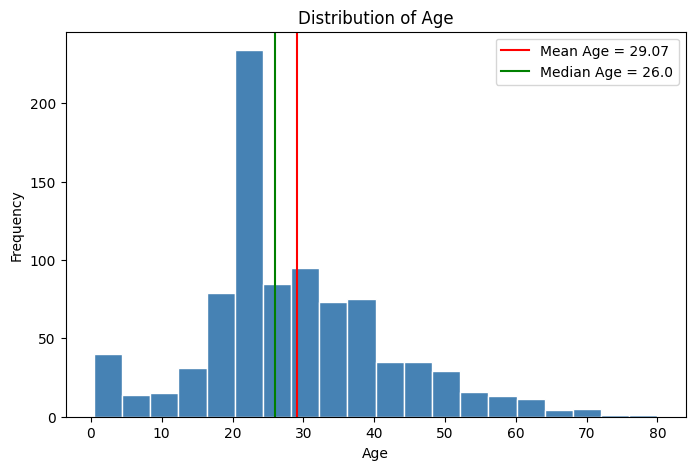

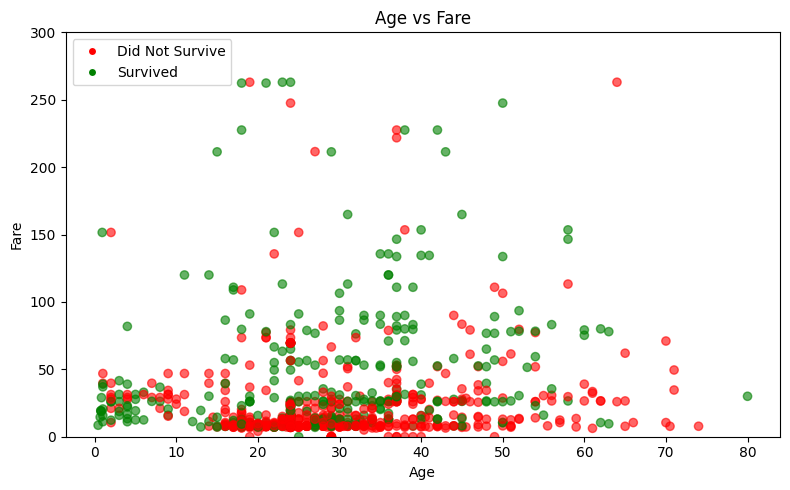

In [15]:
plt.figure(figsize=(8,5))

plt.hist(df["age"],bins = 20,color="steelblue", edgecolor = "white")
plt.axvline(df["age"].mean(), color = "red",label = f"Mean Age = {df["age"].mean():.2f}")

plt.axvline(df["age"].median(), color = "green",label = f"Median Age = {df["age"].median()}")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()


colors = df['survived'].map({
    0:'red',
    1:'green'
})

plt.figure(figsize=(8,5))

plt.scatter(
    df['age'],
    df['fare'],
    c=colors,
    alpha=0.6
)

plt.ylim(0,300)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='red', label='Did Not Survive'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='green', label='Survived')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [17]:
advertising = pd.read_csv("advertising.csv")
advertising

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [18]:
print("Shape:", advertising.shape)

print("\nData Types")
print(advertising.dtypes)

print("\nMissing Values")
print(advertising.isnull().sum())

print("\nDescribe")
print(advertising.describe())

Shape: (200, 4)

Data Types
TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing Values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Describe
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


#### TV
Range = (0.7 - 296.4)
Spread = 295.7

#### Radio
Range = (0 - 49.6)
Spread = 49.6

#### Newspaper
Range = (0.3 - 114)
Spread = 113.7

#### Sales
Range = (1.6 - 27)
Spread = 25.4

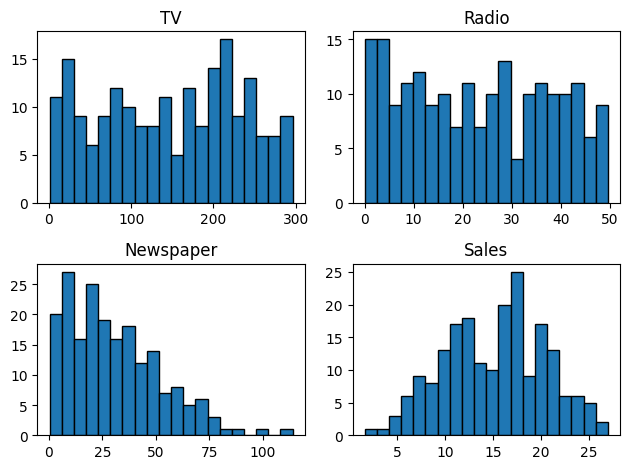

In [19]:
plt.subplot(2,2,1)
plt.hist(advertising["TV"], bins = 20,edgecolor = "k")
plt.title("TV")

plt.subplot(2,2,2)
plt.hist(advertising["Radio"], bins = 20,edgecolor = "k")
plt.title("Radio")

plt.subplot(2,2,3)
plt.hist(advertising["Newspaper"], bins = 20,edgecolor = "k")
plt.title("Newspaper")

plt.subplot(2,2,4)
plt.hist(advertising["Sales"], bins = 20,edgecolor = "k")
plt.title("Sales")

plt.tight_layout()

Are there any apparent outliers just from visual inspection? Note them.


### Q4.2 — Correlation Analysis

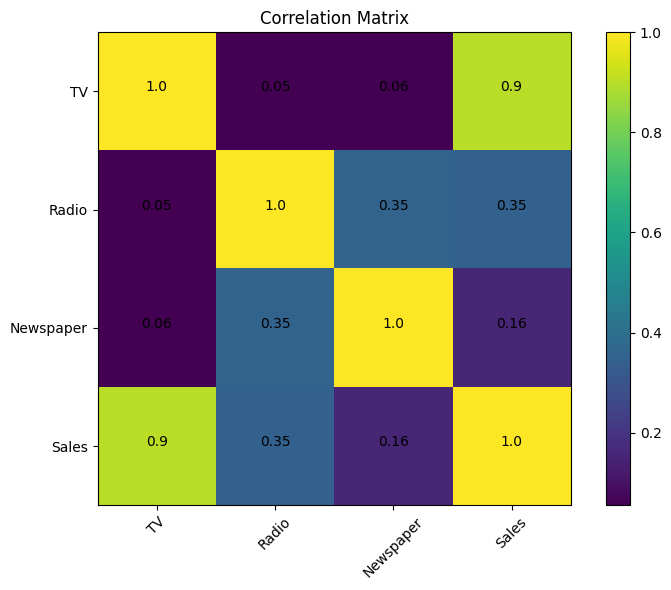

In [20]:
corr = advertising.corr(numeric_only=True)

plt.figure(figsize=(8,6))

im = plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=45)

plt.yticks(range(len(corr.columns)),
           corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(
            j,
            i,
            round(corr.iloc[i,j],2),
            ha='center'
        )

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

1. TV feature is most corelated with sales.
2. TV is poorly corelated with Radio

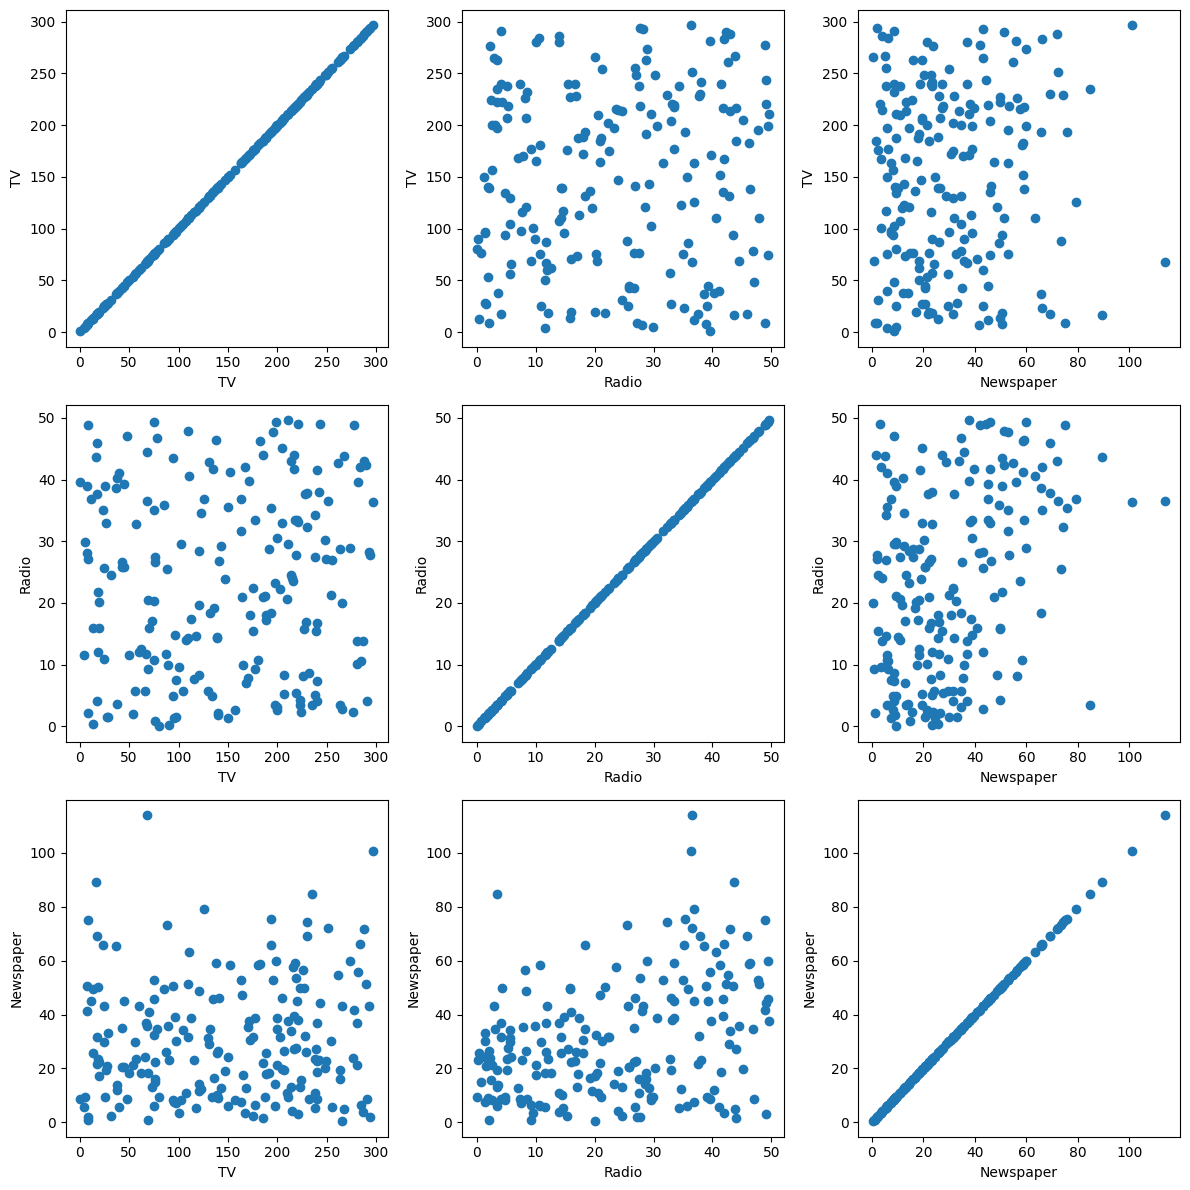

In [21]:
cols = ['TV','Radio','Newspaper']

fig, axes = plt.subplots(3,3, figsize=(12,12))

for i in range(3):
    for j in range(3):
        axes[i,j].scatter(
            advertising[cols[j]],
            advertising[cols[i]]
        )
        axes[i,j].set_xlabel(cols[j])
        axes[i,j].set_ylabel(cols[i])

plt.tight_layout()
plt.show()

### Part 5 — Linear Regression

#### TV

In [22]:
X = advertising['TV'].values
y = advertising['Sales'].values

X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

In [23]:
X = advertising['TV'].values
y = advertising['Sales'].values

X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

In [24]:
x_bar = np.mean(X_train)
y_bar = np.mean(y_train)

m = np.sum(
    (X_train - x_bar)*(y_train - y_bar)
) / np.sum(
    (X_train - x_bar)**2
)

b = y_bar - m*x_bar

print("Slope:", m)
print("Intercept:", b)

y_pred = m * X_test + b

mse = np.mean((y_test - y_pred) ** 2)

print("Test MSE:", mse)

Slope: 0.05572601895005874
Intercept: 6.993686960994353
Test MSE: 5.459799471482253


Radio

In [25]:
X = advertising['Radio'].values
y = advertising['Sales'].values

X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

x_bar = np.mean(X_train)
y_bar = np.mean(y_train)

m_radio = np.sum((X_train - x_bar) * (y_train - y_bar)) / \
          np.sum((X_train - x_bar) ** 2)

b_radio = y_bar - m_radio * x_bar

print("Radio → Sales")
print("Slope (m):", m_radio)
print("Intercept (b):", b_radio)

y_pred = m_radio * X_test + b_radio

mse = np.mean((y_test - y_pred) ** 2)

print("Test MSE:", mse)

Radio → Sales
Slope (m): 0.1239916364053927
Intercept (b): 11.934139103071898
Test MSE: 24.30776581502904


#### Newspaper

In [26]:
X = advertising['Newspaper'].values
y = advertising['Sales'].values

X_train = X[:160]
X_test = X[160:]

y_train = y[:160]
y_test = y[160:]

x_bar = np.mean(X_train)
y_bar = np.mean(y_train)

m_news = np.sum((X_train - x_bar) * (y_train - y_bar)) / \
         np.sum((X_train - x_bar) ** 2)

b_news = y_bar - m_news * x_bar

print("Newspaper → Sales")
print("Slope (m):", m_news)
print("Intercept (b):", b_news)

y_pred = m_news * X_test + b_news

mse = np.mean((y_test - y_pred) ** 2)

print("Test MSE:", mse)

Newspaper → Sales
Slope (m): 0.034786398782922195
Intercept (b): 13.842399973101667
Test MSE: 26.77648521974112


### Q5.2 Sklearn Implementation

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [28]:
X = advertising[['TV']]
y = advertising['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: 0.0554829439314632
Intercept: 7.007108428241848


In [29]:
for dataset, X_data, y_data in [
    ("Train", X_train, y_train),
    ("Test", X_test, y_test)
]:

    pred = model.predict(X_data)

    mae = mean_absolute_error(y_data, pred)
    mse = mean_squared_error(y_data, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_data, pred)

    print(f"\n{dataset}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)


Train
MAE: 1.8005092256620792
MSE: 4.998442356450173
RMSE: 2.235719650683013
R2: 0.8134866044709264

Test
MAE: 1.9502948931650088
MSE: 6.101072906773963
RMSE: 2.470035001123256
R2: 0.802561303423698


The model is well fit as there is not large difference between evaluation metrics of train and test data

## Part 6 — K-Means Clustering

### Q6.1 — Data Exploration

In [30]:
customers = pd.read_csv("Mall_Customers.csv")

In [31]:
customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [32]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [33]:
customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


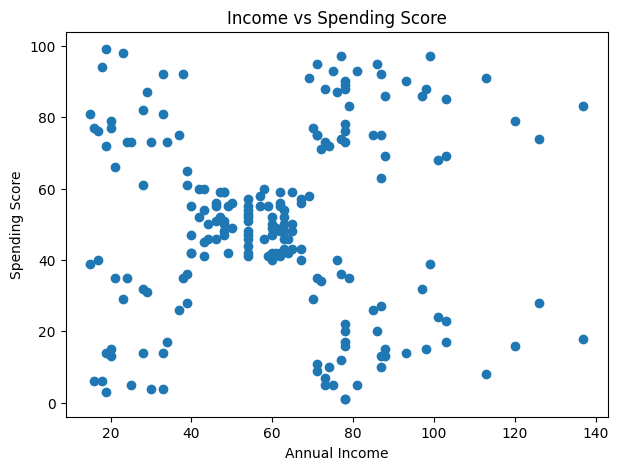

In [34]:
plt.figure(figsize=(7,5))

plt.scatter(
    customers['Annual Income (k$)'],
    customers['Spending Score (1-100)']
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

Visually, around 5 clusters appear reasonable.

### Q6.2 — Apply K-Means

In [35]:
from sklearn.cluster import KMeans

In [36]:
X = customers[
    ['Annual Income (k$)',
     'Spending Score (1-100)']
]

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

customers['Cluster'] = kmeans.fit_predict(X)

In [37]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        'Annual Income',
        'Spending Score'
    ]
)

print(centroids)

   Annual Income  Spending Score
0      55.296296       49.518519
1      86.538462       82.128205
2      25.727273       79.363636
3      88.200000       17.114286
4      26.304348       20.913043


In [38]:
summary = customers.groupby('Cluster').agg({
    'CustomerID':'count',
    'Annual Income (k$)':'mean',
    'Spending Score (1-100)':'mean'
})

print(summary)

         CustomerID  Annual Income (k$)  Spending Score (1-100)
Cluster                                                        
0                81           55.296296               49.518519
1                39           86.538462               82.128205
2                22           25.727273               79.363636
3                35           88.200000               17.114286
4                23           26.304348               20.913043


## Part 7 — Neural Networks on MNIST
### Q7.1 Loading & Preprocessing

In [39]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [40]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [41]:
X_train = X_train / 255.0
X_test = X_test / 255.0

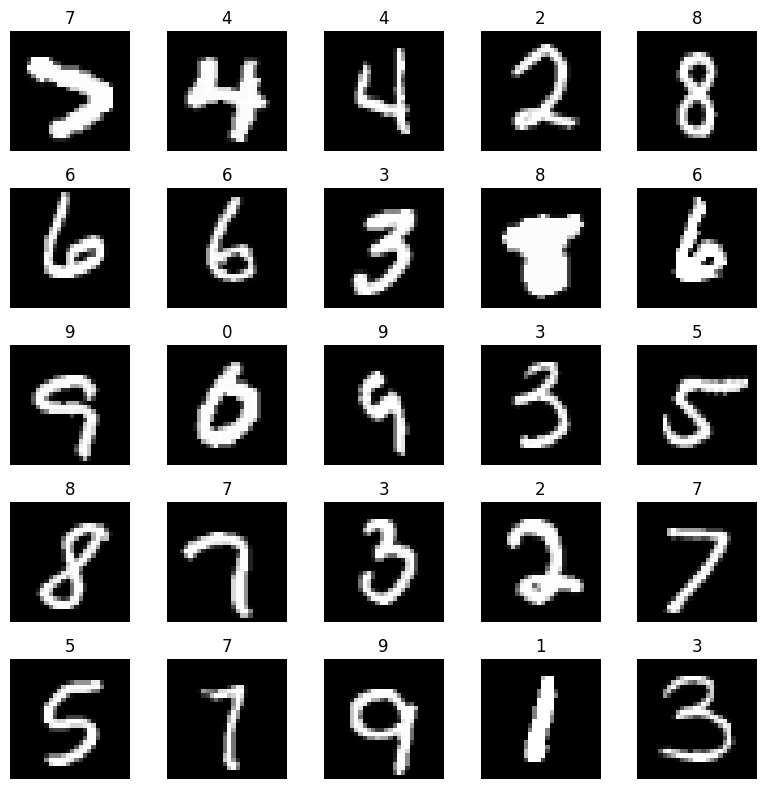

In [42]:
fig, axes = plt.subplots(5,5, figsize=(8,8))

for ax in axes.ravel():

    idx = np.random.randint(0,len(X_train))

    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(y_train[idx])

    ax.axis('off')

plt.tight_layout()
plt.show()

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [44]:
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])vv

C:\Users\ombha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [45]:
ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history_ann = ann.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9216 - loss: 0.2665 - val_accuracy: 0.9569 - val_loss: 0.1457
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.9669 - loss: 0.1116 - val_accuracy: 0.9690 - val_loss: 0.1039
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9759 - loss: 0.0775 - val_accuracy: 0.9725 - val_loss: 0.0946
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.9822 - loss: 0.0569 - val_accuracy: 0.9683 - val_loss: 0.1041
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9854 - loss: 0.0463 - val_accuracy: 0.9685 - val_loss: 0.1166
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9890 - loss: 0.0344 - val_accuracy: 0.9756 - val_loss: 0.0945
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9898 - loss: 0.0301 - val_accuracy: 0.9758 - val_loss: 0.0947
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9918 - 

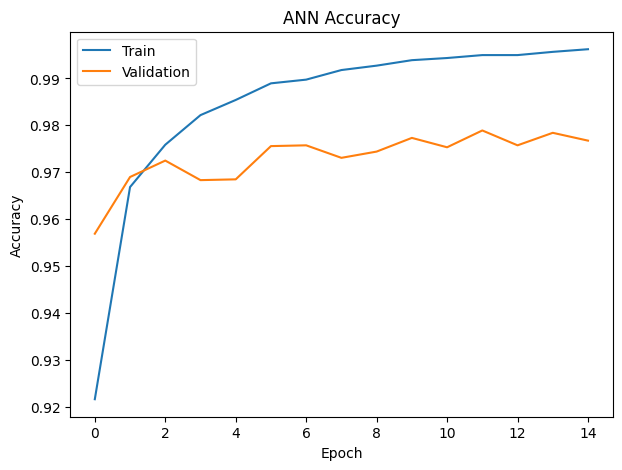

In [48]:

plt.figure(figsize=(7,5))

plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

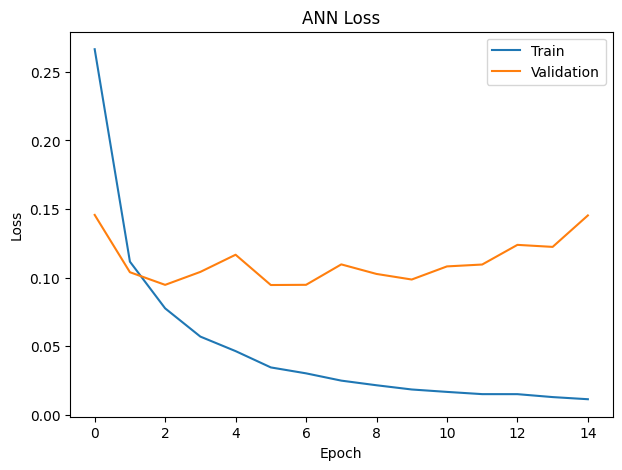

In [49]:
plt.figure(figsize=(7,5))

plt.plot(history_ann.history['loss'])
plt.plot(history_ann.history['val_loss'])

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [50]:
test_loss, test_acc = ann.evaluate(
    X_test,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9768 - loss: 0.1233
Test Loss: 0.1232575923204422
Test Accuracy: 0.9768000245094299


In [51]:
from sklearn.metrics import confusion_matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


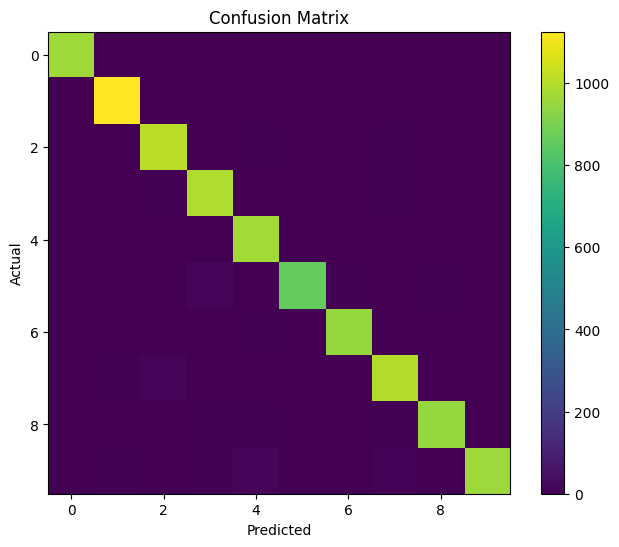

In [52]:
pred = ann.predict(X_test)
pred_labels = np.argmax(pred, axis=1)

cm = confusion_matrix(
    y_test,
    pred_labels
)

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

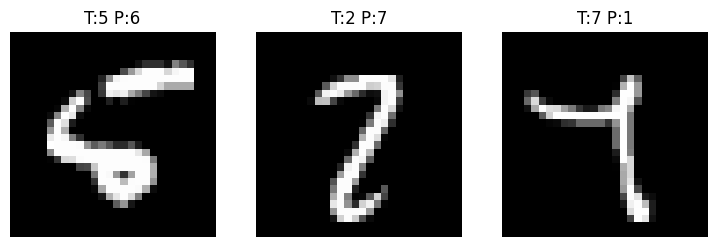

In [53]:
mis = np.where(pred_labels != y_test)[0]

fig, axes = plt.subplots(1,3, figsize=(9,3))

for i in range(3):

    idx = mis[i]

    axes[i].imshow(
        X_test[idx],
        cmap='gray'
    )

    axes[i].set_title(
        f"T:{y_test[idx]} P:{pred_labels[idx]}"
    )

    axes[i].axis('off')

plt.show()

#### CNN

In [54]:
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D
)

In [55]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [56]:
cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

C:\Users\ombha\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [57]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
history_cnn = cnn.fit(
    X_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 68s 42ms/step - accuracy: 0.9571 - loss: 0.1427 - val_accuracy: 0.9833 - val_loss: 0.0577
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 73s 37ms/step - accuracy: 0.9853 - loss: 0.0477 - val_accuracy: 0.9875 - val_loss: 0.0425
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9894 - loss: 0.0325 - val_accuracy: 0.9857 - val_loss: 0.0466
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9931 - loss: 0.0226 - val_accuracy: 0.9869 - val_loss: 0.0435
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 61s 41ms/step - accuracy: 0.9944 - loss: 0.0178 - val_accuracy: 0.9890 - val_loss: 0.0398
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 44ms/step - accuracy: 0.9956 - loss: 0.0133 - val_accuracy: 0.9881 - val_loss: 0.0463
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 62s 41ms/step - accuracy: 0.9960 - loss: 0.0109 - val_accuracy: 0.9911 - val_loss: 0.0412
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.9975 -

In [60]:
cnn_loss, cnn_acc = cnn.evaluate(
    X_test_cnn,
    y_test
)

print("CNN Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9887 - loss: 0.0453
CNN Test Accuracy: 0.9886999726295471


In [61]:
comparison = pd.DataFrame({

    "Model":[
        "Feedforward NN",
        "CNN"
    ],

    "Parameters":[
        ann.count_params(),
        cnn.count_params()
    ],

    "Train Acc":[
        history_ann.history['accuracy'][-1],
        history_cnn.history['accuracy'][-1]
    ],

    "Val Acc":[
        history_ann.history['val_accuracy'][-1],
        history_cnn.history['val_accuracy'][-1]
    ],

    "Test Acc":[
        test_acc,
        cnn_acc
    ],

    "Epochs":[
        15,
        10
    ]
})

comparison

,Model,Parameters,Train Acc,Val Acc,Test Acc,Epochs
0,Feedforward NN,109386,0.996229,0.976750,0.9768,15
1,CNN,225034,0.998396,0.989167,0.9887,10
